In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [8]:
#This is ma 4th model from scratch, hohoo!
class perceptron:
    def __init__(self, learning_rate = 0.01, iter = 600):
        self.iteration = iter
        self.lr = learning_rate
        self.weight = None
        self.bias = None
    def fit(self, X, y):
        self.errors = []
        samples, features = X.shape
        self.weight = np.zeros(features)
        self.bias = 0
        for i in range(self.iteration):
            errors = 0
            for j, x_i in enumerate(X):
                linear = np.dot(x_i, self.weight) + self.bias
                y_hat = self.func(linear)
                if y[j] != y_hat:
                    updating = self.lr * (y[j] - y_hat)
                    self.weight += updating * x_i
                    self.bias += updating
                    errors += 1
            self.errors.append(errors)
    def prediction(self, X):
        linear = np.dot(X, self.weight) + self.bias
        y_hat = self.func(linear)
        return y_hat
    def func(self, x):
            # this is a threshold that outputs 1 or 0
            return np.where(x >= 0, 1, 0)

Accuracy:  1.0
Weights:  [0.012 0.014]
bias:  -0.04
predictions:  [1 1 1 1 0 0 0 1 0 0 0 1 0 0 0 1 1 0 1 1]


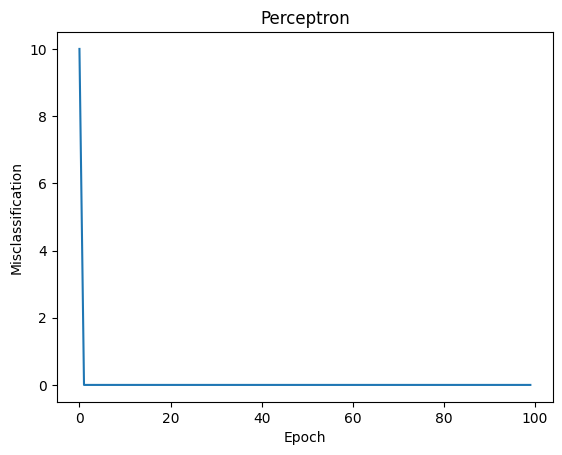

In [16]:
iris = pd.read_csv('iris.csv')
iris = iris[iris['variety'].isin(['Setosa', 'Versicolor'])]
X = iris[['petal.length', 'petal.width']].to_numpy()
y = iris['variety'].map({'Setosa': 0, 'Versicolor': 1}).to_numpy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)
per = perceptron(learning_rate= 0.01, iter= 100)
per.fit(X_train, y_train)
predicts = per.prediction(X_test)
accu = np.mean(predicts == y_test)

print('Accuracy: ',accu)
print('Weights: ', per.weight)
print('bias: ', per.bias)
print('predictions: ', predicts)

plt.plot(per.errors)
plt.xlabel('Epoch')
plt.ylabel('Misclassification')
plt.title('Perceptron')
plt.show()


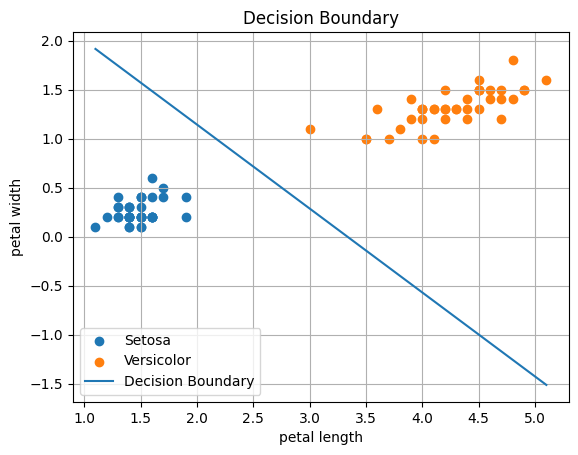

In [17]:
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], label = 'Setosa')
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], label = 'Versicolor')
x_ = np.linspace(X_train[:, 0].min(), X_train[:, 0].max(),100)
y_ = -(per.weight[0] * x_ + per.bias) / per.weight[1]
plt.plot(x_, y_, label = 'Decision Boundary')
plt.xlabel('petal length')
plt.ylabel('petal width')
plt.title('Decision Boundary')
plt.legend()
plt.grid()
plt.show()